In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.transforms.v2 as v2
import torch.nn.functional as F
import importlib
# import software.quant_nn as quant_nn
import quant_nn as quant_nn
importlib.reload(quant_nn)
# import software.quant_nn as quant_nn
import quant_nn as quant_nn

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [3]:
# transform = v2.Compose(
#     [
#         v2.ToImage(),
#         v2.ToDtype(torch.float32, scale=True),
#         v2.Normalize(mean=(0.5,), std=(0.5,)),
#     ]
# )

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        
    ]
)

training_data = datasets.MNIST(root="data", download=True, train=True, transform=transform)

testing_data = datasets.MNIST(root="data", download=True, train=False, transform=transform)

train_loader = DataLoader(dataset=training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=testing_data, batch_size=1000, shuffle=False)
quantizer = quant_nn.FakeQuantizationLayer(1, 7).to(device)

# Comparing Models

In [4]:
uq_model = quant_nn.UnquantizedMLP(128).to(device)
uq_loss_fn = nn.CrossEntropyLoss()
uq_optimizer = optim.Adam(uq_model.parameters(), lr=1e-3)
uq = {'model': uq_model, 'loss_fn': uq_loss_fn, 'opt': uq_optimizer}

In [5]:
# q_nb_model = quant_nn.QuantizedMLP(128, quantizer).to(device)
# q_nb_loss_fn = nn.CrossEntropyLoss()
# q_nb_optimizer = optim.Adam(q_nb_model.parameters(), lr=1e-3)
# q_nb = {"model": q_nb_model, "loss_fn": q_nb_loss_fn, "opt": q_nb_optimizer}

In [6]:
q_b_model = quant_nn.QuantizedMLP(128, quantizer, quant_bias=True).to(device)
q_b_loss_fn = nn.CrossEntropyLoss()
q_b_optimizer = optim.Adam(q_b_model.parameters(), lr=1e-3)
q_b = {"model": q_b_model, "loss_fn": q_b_loss_fn, "opt": q_b_optimizer}

In [7]:
q_bc_model = quant_nn.QuantizedMLP(128, quantizer, quant_bias=True, clip_out=True).to(device)
q_bc_loss_fn = nn.CrossEntropyLoss()
q_bc_optimizer = optim.Adam(q_bc_model.parameters(), lr=1e-3)
q_bc = {"model": q_bc_model, "loss_fn": q_bc_loss_fn, "opt": q_bc_optimizer}

In [9]:
groups = [uq, q_b, q_bc]

for g in groups:
    model = g['model']
    loss_fn = g['loss_fn']
    optimizer = g['opt']
    quant_nn.train(model, train_loader, loss_fn, optimizer, epochs=5, device=device)
    quant_nn.test(model, test_loader, device=device)
    print('-'*100)
    

Loss: 0.0654
Accuracy on test set: 97.580000%
----------------------------------------------------------------------------------------------------
Loss: 0.0739
Accuracy on test set: 96.910000%
----------------------------------------------------------------------------------------------------
Loss: 0.8478
Accuracy on test set: 97.040000%
----------------------------------------------------------------------------------------------------


In [10]:
for e in [5, 10, 15, 20, 50]:
    print('*'*100)
    print(e)
    for g in groups:
        model = g["model"]
        loss_fn = g["loss_fn"]
        optimizer = g["opt"]
        quant_nn.train(model, train_loader, loss_fn, optimizer, epochs=5, device=device)
        quant_nn.test(model, test_loader, device=device)
        print("-" * 100)

****************************************************************************************************
5
Loss: 0.0231
Accuracy on test set: 97.970000%
----------------------------------------------------------------------------------------------------
Loss: 0.0305
Accuracy on test set: 97.330000%
----------------------------------------------------------------------------------------------------
Loss: 0.8281
Accuracy on test set: 97.190000%
----------------------------------------------------------------------------------------------------
****************************************************************************************************
10
Loss: 0.0097
Accuracy on test set: 97.600000%
----------------------------------------------------------------------------------------------------
Loss: 0.0154
Accuracy on test set: 97.340000%
----------------------------------------------------------------------------------------------------
Loss: 0.8206
Accuracy on test set: 97.210000%
------------

In [ ]:
model = uq_model
for name, param in model.named_parameters():
    print(f"{name}: min={param.min().item():.4f}, max={param.max().item():.4f}")

# print("layer1.weight:", model.layer1.weight.min().item(), model.layer1.weight.max().item())
# print("layer2.weight:", model.layer2.weight.min().item(), model.layer2.weight.max().item())

layer1.weight: min=-0.7725, max=0.4607
layer1.bias: min=-0.1368, max=0.2639
layer2.weight: min=-0.8507, max=0.5604
layer2.bias: min=-0.0937, max=0.1618


# PTQ

In [ ]:
def quantize_state_dict(model, int_bits, frac_bits):
    scale = 2**frac_bits
    total_bits = int_bits + frac_bits
    q_min = -(1 << (total_bits - 1))
    q_max = (1 << (total_bits - 1)) - 1

    quantized = {}
    for name, param in model.state_dict().items():
        x_int = torch.clamp(torch.round(param * scale), q_min, q_max)
        quantized[name] = x_int.to(torch.int8)  # int8 fits total_bits=8 exactly
    return quantized




In [ ]:
q_weights = quantize_state_dict(q_b_model, int_bits=1, frac_bits=7)
torch.save(q_weights, "q_b_model_int8.pt")

import numpy as np

np.savez("q_b_model_int8.npz", **{k: v.cpu().numpy() for k, v in q_weights.items()})

ptq_model = quant_nn.QuantizedMLP(128, quantizer, quant_bias=True).to(device)
ptq_model.load_state_dict(uq_model.state_dict())  # trained fp32 weights, zero fine-tuning
test(ptq_model, test_loader)

m1 = quant_nn.QuantizedMLP(128, quantizer, quant_bias=True).to(device)
m1.load_state_dict(q_b_model.state_dict())  # trained fp32 weights, zero fine-tuning
test(m1, test_loader)

Accuracy on test set: 91.290000%
Accuracy on test set: 97.100000%


# Investigating Activation Values

In [ ]:
model = quant_nn.QuantizedMLP(128, quantizer, quant_bias=True).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
quant_nn.train(model, train_loader, loss_fn, optimizer, device, print_output=False, epochs=5)

Loss: 0.0710


In [ ]:
quant_nn.test(model, test_loader, device)

Accuracy on test set: 97.120000%


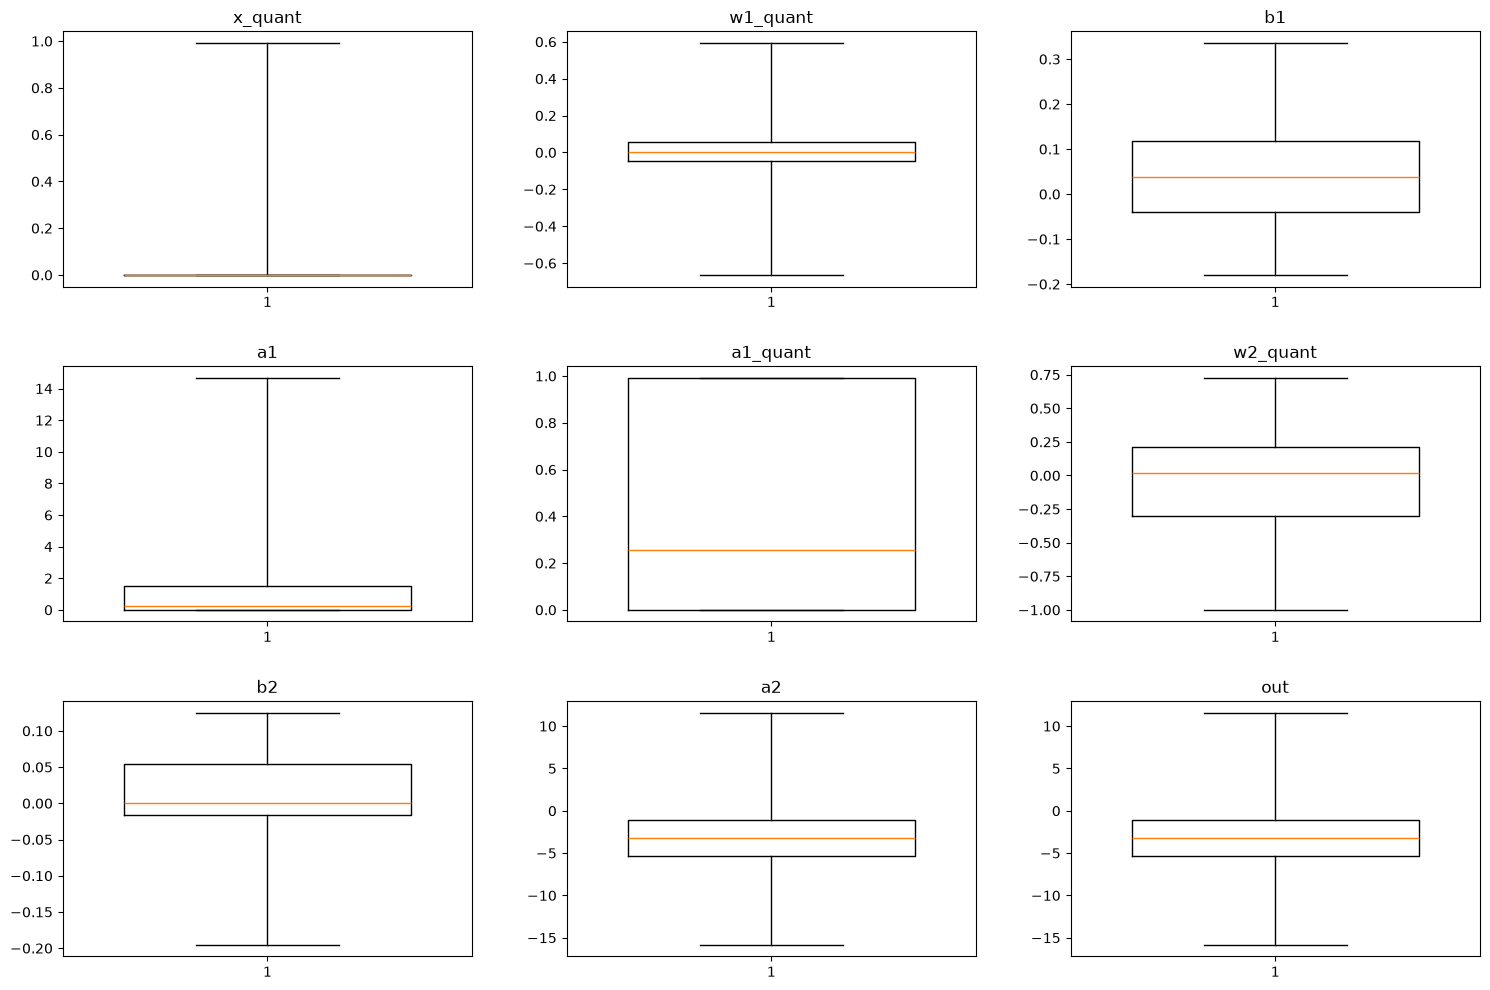

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes_flat = axes.flatten()
for i, (key, value) in enumerate(model.debug.items()):
    n = torch.stack(value).numpy(force=True).flatten()
    axes_flat[i].boxplot(n, showfliers=False, widths=0.7, whis=(0, 100))
    axes_flat[i].set_title(key)

plt.tight_layout(h_pad=2.5, w_pad=3.0)
plt.show()

In [ ]:
summary = quant_nn.collect_activation_stats(model, test_loader, device=device)
for name, s in summary.items():
    print(f"{name:10s} min={s['min']:8.4f} max={s['max']:8.4f} mean={s['mean']:8.4f} std={s['std']:8.4f}")

x_quant    min=  0.0000 max=  0.9922 mean=  0.1323 std=  0.3098
w1_quant   min= -0.8281 max=  0.6094 mean=  0.0015 std=  0.0892
b1         min= -0.1953 max=  0.2500 mean=  0.0397 std=  0.0969
a1         min=  0.0000 max= 12.9377 mean=  0.8632 std=  1.2213
a1_quant   min=  0.0000 max=  0.9922 mean=  0.4322 std=  0.4578
w2_quant   min= -1.0000 max=  0.9531 mean= -0.0561 std=  0.3376
b2         min= -0.1094 max=  0.1094 mean= -0.0297 std=  0.0764
a2         min=-15.4587 max= 13.3395 mean= -2.7719 std=  4.0473
out        min=-15.4587 max= 13.3395 mean= -2.7719 std=  4.0473
